In [2]:
from kaggle_secrets import UserSecretsClient
from roboflow import Roboflow
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
import cv2
import os
from PIL import Image
import random
from collections import Counter
import yaml
import pandas as pd

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("ROBOFLOW_API_KEY")

In [4]:
rf = Roboflow(api_key = secret_value_0)
project = rf.workspace("shubham-fe5g7").project("license-plate-recognition-rxg4e-k9rop")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-1 in yolov11:: 100%|██████████| 20255/20255 [00:02<00:00, 8665.50it/s] 


In [5]:
train_dir = '/kaggle/working/License-Plate-Recognition-1/train'
test_dir = '/kaggle/working/License-Plate-Recognition-1/test'
val_dir = '/kaggle/working/License-Plate-Recognition-1/valid'

# Data Preprocessing 

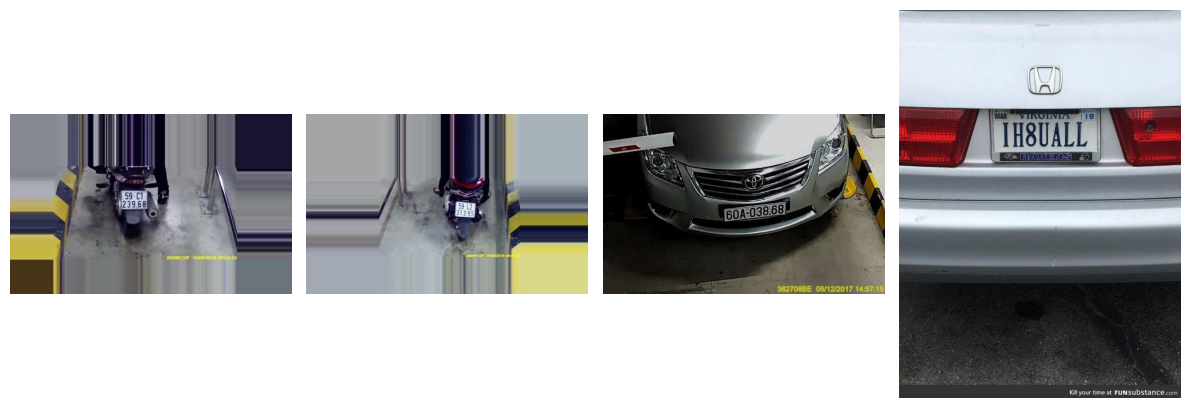

In [6]:
number_of_imgs = 4
imgs = os.listdir(os.path.join(train_dir, 'images'))

sample_imgs = random.sample(
    imgs,
    min(number_of_imgs, len(imgs))
)

plt.figure(figsize=(12, 8))

for i, img in enumerate(sample_imgs, 1):
    plt.subplot(1, number_of_imgs, i)
    plt.imshow(
        Image.open(os.path.join(train_dir, 'images', img)),
        cmap = 'gray'
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
print(f'Total Train Images : {len(os.listdir(os.path.join(train_dir, 'images')))}')
print(f'Total Test Images : {len(os.listdir(os.path.join(test_dir, 'images')))}')
print(f'Total Validate Images : {len(os.listdir(os.path.join(val_dir, 'images')))}')

Total Train Images : 7057
Total Test Images : 1020
Total Validate Images : 2048


In [8]:
def check_extension(dir, name = None):
    counts = Counter()
    for _, _, filenames in os.walk(os.path.join(dir, 'images')):
        for filename in filenames:
            _, extension = os.path.splitext(filename)
            counts[extension]+=1
    print(f'\n{name} Images Extension:')
    for ext, count in counts.items():
        print(f'{ext} : {count} images')

In [9]:
check_extension(train_dir, 'Train')
check_extension(test_dir, 'Test')
check_extension(val_dir, 'Validation')


Train Images Extension:
.jpg : 7057 images

Test Images Extension:
.jpg : 1020 images

Validation Images Extension:
.jpg : 2048 images


# Model Training

In [10]:
yaml_path = '/kaggle/working/License-Plate-Recognition-1/data.yaml'
with open(yaml_path, 'r') as file:
    data_yaml = yaml.safe_load(file)
data_yaml

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 1,
 'names': ['License_Plate'],
 'roboflow': {'workspace': 'shubham-fe5g7',
  'project': 'license-plate-recognition-rxg4e-k9rop',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/shubham-fe5g7/license-plate-recognition-rxg4e-k9rop/dataset/1'}}

In [11]:
data_yaml['train'] = '/kaggle/working/License-Plate-Recognition-1/train/images'
data_yaml['val'] = '/kaggle/working/License-Plate-Recognition-1/valid/images'
data_yaml['test'] = '/kaggle/working/License-Plate-Recognition-1/test/images'

In [12]:
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

In [13]:
model = YOLO('yolo11s.pt')

In [14]:
model.train(data = '/kaggle/working/License-Plate-Recognition-1/data.yaml', 
            epochs = 100, 
            patience = 20,
            batch = 42, 
            device = 'cuda', 
            imgsz = 320,
            cache = True)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=42, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/License-Plate-Recognition-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a7b1cc4d070>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [16]:
result_path = '/kaggle/working/runs/detect/train/results.csv'
with open(result_path, 'r') as file:
    result = pd.read_csv(file)

result

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,89.2262,1.30745,1.18329,1.07819,0.92444,0.89112,0.90754,0.56250,1.27969,0.67842,1.00950,0.009941,0.003314,0.009941,0.003314,0.009941,0.003314,0.009941,0.003314
1,2,153.6300,1.26271,0.75834,1.01302,0.69672,0.76173,0.73793,0.41949,1.38186,2.54134,1.14278,0.019743,0.006581,0.019743,0.006581,0.019743,0.006581,0.019743,0.006581
2,3,215.9340,1.33546,0.82790,1.09758,0.73795,0.72998,0.75126,0.44384,1.44752,1.34382,1.33978,0.029348,0.009783,0.029348,0.009783,0.029348,0.009783,0.029348,0.009783
3,4,266.4020,1.30276,0.73449,1.10768,0.94011,0.80817,0.86039,0.52615,1.41099,0.91839,1.24175,0.029109,0.009703,0.029109,0.009703,0.029109,0.009703,0.029109,0.009703
4,5,315.7220,1.25958,0.68139,1.10191,0.94775,0.86770,0.91451,0.57745,1.26901,0.71392,1.17029,0.028812,0.009604,0.028812,0.009604,0.028812,0.009604,0.028812,0.009604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,4879.1800,0.82786,0.32324,0.94103,0.98660,0.93926,0.95389,0.67584,1.05080,0.37478,1.01441,0.001785,0.000595,0.001785,0.000595,0.001785,0.000595,0.001785,0.000595
96,97,4928.9400,0.82342,0.32058,0.93542,0.98524,0.94351,0.96097,0.67546,1.05070,0.37465,1.01460,0.001488,0.000496,0.001488,0.000496,0.001488,0.000496,0.001488,0.000496
97,98,4979.0100,0.81842,0.31677,0.93427,0.98518,0.94442,0.96157,0.67521,1.05163,0.37462,1.01517,0.001191,0.000397,0.001191,0.000397,0.001191,0.000397,0.001191,0.000397
98,99,5028.7800,0.81803,0.31381,0.93270,0.98207,0.94533,0.96077,0.67526,1.05158,0.37269,1.01522,0.000894,0.000298,0.000894,0.000298,0.000894,0.000298,0.000894,0.000298


In [17]:
result.columns = result.columns.str.strip()
epochs = range(1, len(result.index)+1)
epochs

range(1, 101)

In [18]:
result.columns 

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6',
       'lr/pg7'],
      dtype='object')

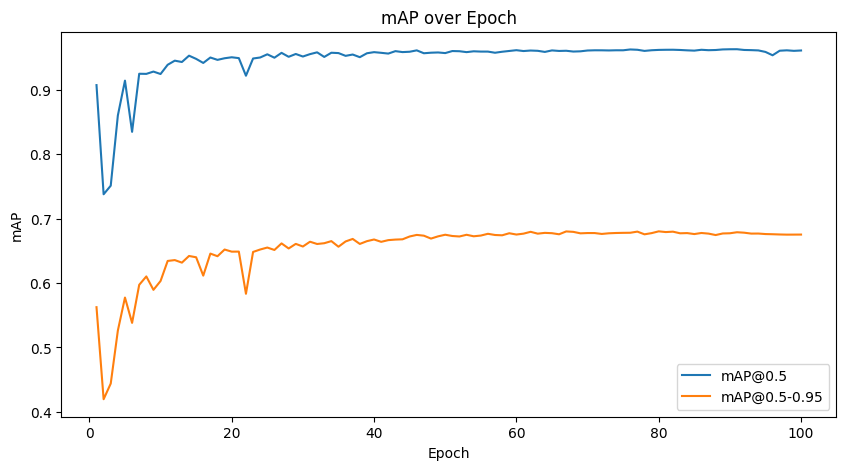

In [19]:
map_0_5 = result['metrics/mAP50(B)']
map_0_5_0_95 = result['metrics/mAP50-95(B)']

plt.figure(figsize = (10, 5))
plt.plot(epochs, map_0_5, label = 'mAP@0.5')
plt.plot(epochs, map_0_5_0_95, label = 'mAP@0.5-0.95')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('mAP over Epoch')
plt.legend()
plt.show()

In [20]:
model.save('yolo11s-model.pt')

In [21]:
def predict_and_plot(test_img_path):
    prediction = model.predict(test_img_path)
    image = cv2.imread(test_img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    for pred in prediction:
        for box in pred.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = box.conf[0]
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label = f'License Plate | {confidence * 100:.1f}%'
            cv2.putText(image, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2, cv2.LINE_AA)
    plt.imshow(image)
    plt.axis('off') 
    plt.show()


image 1/1 /kaggle/working/License-Plate-Recognition-1/test/images/0002a5b67e5f0909_jpg.rf.f88798ecde4d01ca78b4dfa7e82c9226.jpg: 256x320 2 License_Plates, 56.3ms
Speed: 1.0ms preprocess, 56.3ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 320)


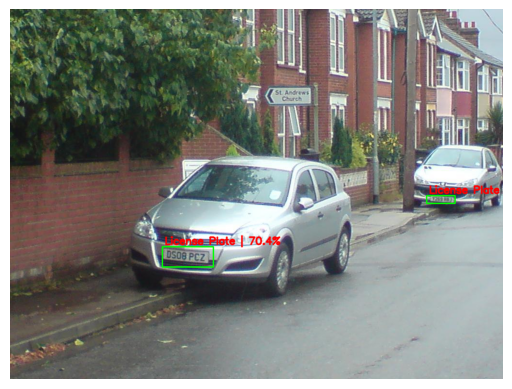

In [22]:
predict_and_plot('/kaggle/working/License-Plate-Recognition-1/test/images/0002a5b67e5f0909_jpg.rf.f88798ecde4d01ca78b4dfa7e82c9226.jpg')


image 1/1 /kaggle/working/License-Plate-Recognition-1/test/images/00e481ea1a520175_jpg.rf.62486a7a9c5679d3a49ce090965febe2.jpg: 256x320 1 License_Plate, 9.8ms
Speed: 1.0ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 320)


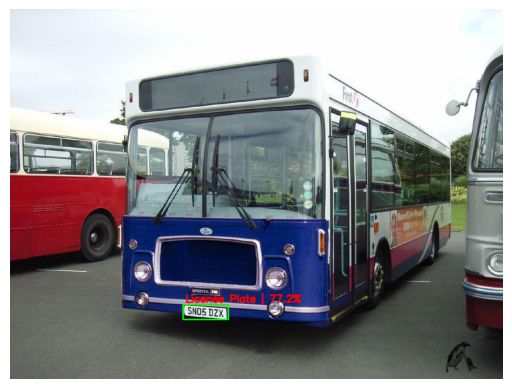

In [23]:
predict_and_plot('/kaggle/working/License-Plate-Recognition-1/test/images/00e481ea1a520175_jpg.rf.62486a7a9c5679d3a49ce090965febe2.jpg')


image 1/1 /kaggle/working/License-Plate-Recognition-1/test/images/589222_jpg.rf.d45b559a109944d96cc131b3715037be.jpg: 320x320 1 License_Plate, 10.2ms
Speed: 1.1ms preprocess, 10.2ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 320)


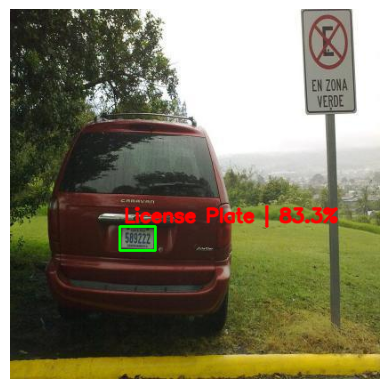

In [24]:
predict_and_plot('/kaggle/working/License-Plate-Recognition-1/test/images/589222_jpg.rf.d45b559a109944d96cc131b3715037be.jpg')